# Detección de Noticias Falsas en Español mediante PLN y Arquitecturas Transformer

**Proyecto:** Chatbot para la detección de noticias falsas.
**Materia:** Procesamiento del Lenguaje Natural (PLN).

Este cuaderno documenta el desarrollo experimental del proyecto, organizado en cuatro fases: (1) adquisición y análisis exploratorio de los datos, (2) preprocesamiento y tokenización, (3) ajuste fino (*fine-tuning*) de un modelo Transformer, y (4) evaluación sobre el conjunto de prueba. Cada fase se acompaña de una introducción que motiva sus objetivos y de una conclusión que sintetiza los hallazgos obtenidos.

## Instalación de dependencias

La siguiente celda agrupa todas las bibliotecas necesarias para ejecutar el cuaderno. Conviene ejecutarla una sola vez al inicio y, a continuación, reiniciar el *kernel* (*Kernel → Restart*) para que los paquetes queden correctamente disponibles. PyTorch se instala con soporte para GPU (CUDA); el sufijo `cuXXX` debe ajustarse a la versión de CUDA del equipo (véase pytorch.org). En un equipo sin GPU NVIDIA puede omitirse el índice de CUDA e instalarse la versión para CPU.

In [ ]:
# 1. Bibliotecas base para manipulación y visualización de datos
%pip install -q pandas numpy matplotlib seaborn scikit-learn

# 2. Bibliotecas de PLN y aprendizaje profundo
%pip install -q spacy transformers datasets "accelerate>=1.1.0"

# 3. Modelo de spaCy preentrenado para el idioma español
import sys
!{sys.executable} -m spacy download es_core_news_md

# 4. PyTorch con soporte para GPU (CUDA). Ajustar 'cu130' a la versión de CUDA del equipo.
%pip install -q torch --index-url https://download.pytorch.org/whl/cu130

# 5. torchvision no se utiliza y generaba un conflicto de importación con transformers; se desinstala.
%pip uninstall -y torchvision

In [ ]:
# Verificación: comprobar que PyTorch detecta la GPU
import torch
print("¿GPU disponible?:", torch.cuda.is_available())

# Fase 1: Adquisición y Análisis Exploratorio de Datos (EDA)

En esta fase se carga el conjunto de datos `spanishFakeNews.csv` y se realiza una limpieza inicial (eliminación de valores nulos y duplicados), para luego explorar sus características fundamentales: el balance entre clases, la distribución de la longitud de los textos y la extracción de entidades nombradas mediante spaCy. Estos análisis orientan decisiones posteriores, como el tratamiento del desbalance y la elección de la longitud máxima de secuencia.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import numpy as np

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
import os 
path_dir = os.getcwd()
try :
    df = pd.read_csv(os.path.join(path_dir,'data','spanishFakeNews.csv'))
except FileNotFoundError :
    print("Error: cannot find dataset")
display(df.head())

,texto,clase
0,El año pasado la Ciudad de México se estremeci...,fake
1,Manuela Carmena pide a los madrileños que guar...,fake
2,Una fuerte sorpresa se llevó el todavía presid...,fake
3,La 1 de Televisión Española repitió ayer como ...,fake
4,685 curas católicos fueron acusados de abuso s...,real


In [3]:

df.columns = df.columns.str.lower()

# Asumiendo que la columna de texto se llama 'text' y la etiqueta 'label'
text_col = 'texto' if 'texto' in df.columns else df.columns[0] # Ajustar si es necesario
label_col = 'clase' if 'clase' in df.columns else df.columns[-1] # Ajustar si es necesario

print(f"Usando la columna '{text_col}' para el texto y '{label_col}' para las etiquetas.\n")

# 2. Eliminar valores nulos
filas_antes = len(df)
df = df.dropna(subset=[text_col, label_col])
print(f"Valores nulos eliminados: {filas_antes - len(df)}")

# 3. Eliminar duplicados
filas_antes = len(df)
df = df.drop_duplicates(subset=[text_col])
print(f"Textos duplicados eliminados: {filas_antes - len(df)}")

print(f"Tamaño del dataset tras la limpieza: {df.shape[0]} noticias.")

Usando la columna 'texto' para el texto y 'clase' para las etiquetas.

Valores nulos eliminados: 0
Textos duplicados eliminados: 0
Tamaño del dataset tras la limpieza: 538 noticias.


Distribución de clases:
clase
real    305
fake    233
Name: count, dtype: int64


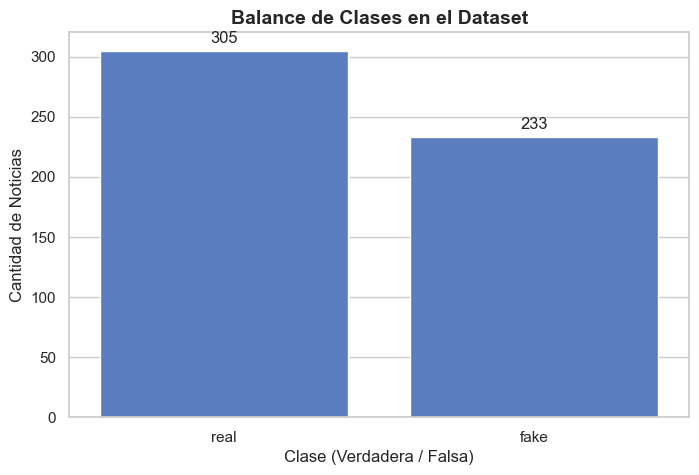

In [4]:
# Analizar el balance de clases (Noticias Verdaderas vs Falsas)
conteo_clases = df[label_col].value_counts()

print("Distribución de clases:")
print(conteo_clases)

# Visualización
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=conteo_clases.index, y=conteo_clases.values)
plt.title('Balance de Clases en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Clase (Verdadera / Falsa)', fontsize=12)
plt.ylabel('Cantidad de Noticias', fontsize=12)

# Añadir las cantidades sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()


Estadísticas de longitud de palabras:


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
fake,233.0,360.982833,190.918424,11.0,250.0,344.0,467.0,1173.0
real,305.0,402.826230,413.877190,22.0,216.0,316.0,471.0,4669.0


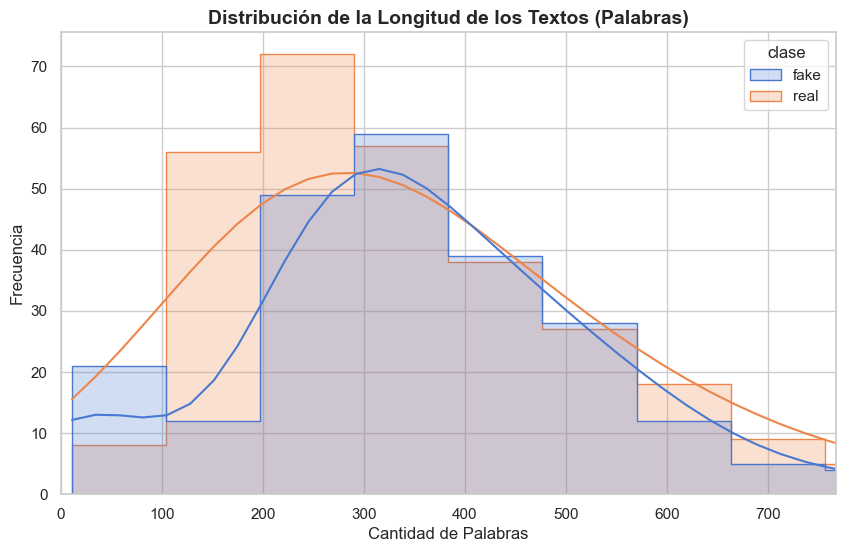

In [5]:
# Calcular la longitud de cada noticia en palabras
df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))

print("\nEstadísticas de longitud de palabras:")
display(df.groupby(label_col)['word_count'].describe())

# Visualización de la distribución de longitudes
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue=label_col, bins=50, kde=True, element="step")
plt.title('Distribución de la Longitud de los Textos (Palabras)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Palabras', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# Limitar el eje X para evitar valores atípicos extremos que deformen el gráfico
plt.xlim(0, df['word_count'].quantile(0.95)) 
plt.show()

In [6]:
# Cargar el modelo en español de spaCy (el especificado en tu informe)
try:
    nlp = spacy.load("es_core_news_md")
    print("Modelo 'es_core_news_md' cargado correctamente.\n")
except OSError:
    print("Error: El modelo de spaCy no está instalado. Ejecuta: !python -m spacy download es_core_news_md")
    nlp = None

if nlp:
    # Tomar un ejemplo aleatorio del dataset
    ejemplo_texto = df[text_col].iloc[0]
    etiqueta = df[label_col].iloc[0]
    
    print(f"--- EJEMPLO DE NOTICIA ({etiqueta}) ---")
    # Mostrar solo los primeros 500 caracteres para no saturar la pantalla
    print(str(ejemplo_texto)[:500] + "...\n")
    
    # Procesar el texto
    doc = nlp(str(ejemplo_texto))
    
    # Extraer y contar entidades
    entidades = [(ent.text, ent.label_) for ent in doc.ents]
    
    print("--- ENTIDADES ENCONTRADAS ---")
    if entidades:
        df_entidades = pd.DataFrame(entidades, columns=['Entidad', 'Tipo'])
        display(df_entidades.head(10)) # Mostrar las primeras 10 entidades
        print(f"\nTotal de entidades extraídas en este ejemplo: {len(entidades)}")
    else:
        print("No se encontraron entidades nombradas en este ejemplo.")

Modelo 'es_core_news_md' cargado correctamente.

--- EJEMPLO DE NOTICIA (fake) ---
El año pasado la Ciudad de México se estremeció luego de que se anunciara que Godzilla llegaría a la ciudad , pero no de forma literal porque el mounstro ni siquiera existe en la vida real, sino que los productores filmarían escenas de la nueva película lo que originó una gran expectativa y sobre todo, divertidos chistes y memes sobre el fatal destino que tendría Godzilla al pisar nuestro país. Fue poco lo que se supo del tema, principalmente porque el rodaje fue más rápido de lo que se esperaba...

--- ENTIDADES ENCONTRADAS ---


,Entidad,Tipo
0,Ciudad de México,LOC
1,Godzilla,PER
2,Godzilla,MISC
3,James Bond,PER
4,Spectre,PER
5,Godzilla,PER
6,Como estas películas,MISC
7,Godzilla,MISC
8,Godzilla,LOC
9,México,LOC



Total de entidades extraídas en este ejemplo: 25


Conteo total por tipo y clase:
       fake  real
LOC    904  2546
MISC  1839  3064
ORG    739  1552
PER   1570  2070 

Entidades promedio por noticia (por clase):
 clase
fake    21.68
real    30.27
Name: n_ents, dtype: float64 

Top LOC: {'México': 105, 'Ecuador': 87, 'Estados Unidos': 83, 'España': 64, 'Quito': 53}
Top MISC: {'Miss Universo': 58, 'Twitter': 34, 'Ahora': 31, 'Miss España': 28, 'Navidad': 20}
Top ORG: {'Boca': 32, 'PT': 29, 'River': 20, 'ICIJ': 20, 'FEF': 18}
Top PER: {'Trump': 42, 'AMLO': 33, 'Juan Gabriel': 32, 'López Obrador': 28, 'Obrador': 27}


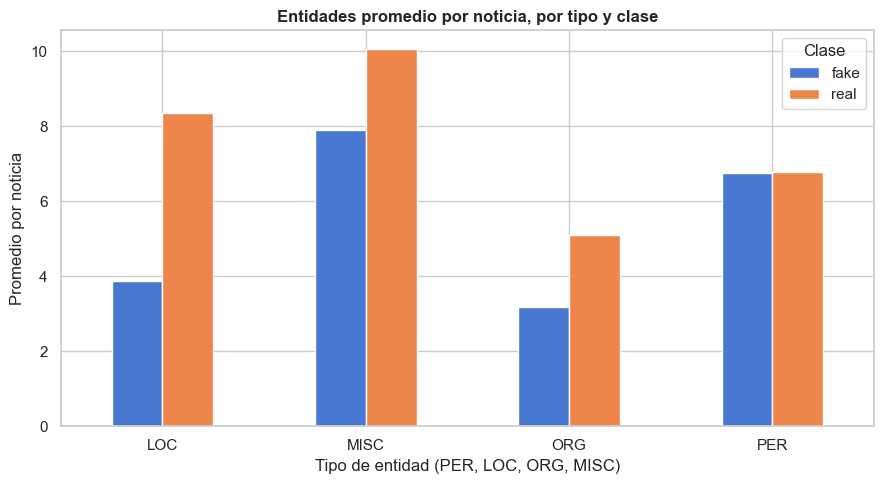

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import spacy

# Modelo real (en Colab/local se descarga sin problema)
nlp = spacy.load("es_core_news_md", disable=["morphologizer", "parser",
                                             "attribute_ruler", "lemmatizer"])

def analizar_ner(df, nlp, text_col, label_col, muestra=None, seed=42):
    """Procesa los textos y agrega las entidades por tipo y por clase."""
    data = df if muestra is None else df.sample(min(muestra, len(df)), random_state=seed)
    registros, por_tipo_clase, top_por_tipo = [], Counter(), {}
    for doc, clase in zip(nlp.pipe(data[text_col].astype(str), batch_size=32), data[label_col]):
        ents = list(doc.ents)
        registros.append((clase, len(ents)))
        for ent in ents:
            por_tipo_clase[(clase, ent.label_)] += 1
            top_por_tipo.setdefault(ent.label_, Counter())[ent.text.strip()] += 1
    reg = pd.DataFrame(registros, columns=[label_col, "n_ents"])
    tipos  = sorted({t for (_, t) in por_tipo_clase})
    clases = sorted(reg[label_col].unique())
    tabla = pd.DataFrame(0, index=tipos, columns=clases)
    for (clase, tipo), c in por_tipo_clase.items():
        tabla.loc[tipo, clase] = c
    return tabla, reg, top_por_tipo

# Procesa TODO el dataset
tabla, reg, top = analizar_ner(df, nlp, text_col, label_col)

# Entidades promedio por noticia, por tipo y clase 
n_por_clase = reg[label_col].value_counts()
tabla_prom = tabla.div(n_por_clase, axis=1)

print("Conteo total por tipo y clase:\n", tabla, "\n")
print("Entidades promedio por noticia (por clase):\n",
      reg.groupby(label_col)["n_ents"].mean().round(2), "\n")
for tipo in tabla.index:
    print(f"Top {tipo}:", dict(top.get(tipo, Counter()).most_common(5)))

# Gráfico: entidades promedio por noticia, por tipo y clase
ax = tabla_prom.plot(kind="bar", figsize=(9, 5))
plt.title("Entidades promedio por noticia, por tipo y clase", fontweight="bold")
plt.xlabel("Tipo de entidad (PER, LOC, ORG, MISC)")
plt.ylabel("Promedio por noticia")
plt.xticks(rotation=0)
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

### Conclusiones de la Fase 1
1. **Calidad de los datos:** el conjunto se verificó en busca de valores nulos y duplicados, sin encontrarse ninguno (538 registros antes y después de la limpieza), por lo que los datos están listos para su uso sin pérdida de ejemplos.
2. **Balance de clases:** existen 305 noticias reales (56.7 %) y 233 falsas (43.3 %), lo que representa un desbalance leve (razón de 1.31 : 1). No se requieren técnicas de *data augmentation*; basta con ponderar las clases en la función de pérdida y reportar la métrica F1-macro durante la evaluación.
3. **Longitud de los textos:** el percentil 95 ronda las 767 palabras y se observa un sesgo de longitud (las noticias reales son, en promedio, más largas que las falsas). Este hallazgo es determinante para fijar el parámetro `max_length` en la tokenización y debe tenerse presente al interpretar los resultados, para descartar que el modelo discrimine por longitud.
4. **Reconocimiento de entidades:** la integración con spaCy (modelo `es_core_news_md`) funciona correctamente, lo que valida la viabilidad de extraer personas, lugares y organizaciones para enriquecer la experiencia conversacional del chatbot.

# Fase 2: Preprocesamiento y Tokenización

A diferencia de los modelos clásicos de PLN, las arquitecturas Transformer requieren un preprocesamiento mínimo: no se eliminan palabras vacías (*stopwords*) ni se aplica *stemming*, pues el modelo es contextual y dispone de su propio tokenizador de subpalabras. En esta fase se ejecutan cuatro pasos: una limpieza ligera del texto (que conserva mayúsculas y puntuación, aprovechadas como señal por el modelo *cased*), la codificación numérica de las etiquetas, la partición estratificada en entrenamiento y validación, y la tokenización mediante el tokenizador del modelo preentrenado BETO.

In [9]:
import re
from sklearn.model_selection import train_test_split

def limpiar_ligero(texto):
    """Limpieza mínima: quita URLs y normaliza espacios. Conserva mayúsculas,
    tildes y puntuación, porque BETO (cased) las usa como señal."""
    texto = str(texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)  # URLs
    texto = re.sub(r"\s+", " ", texto)               # espacios y saltos múltiples
    return texto.strip()

df["texto_limpio"] = df[text_col].apply(limpiar_ligero)

# Etiquetas -> número. Tratamos 'fake' como clase positiva (1): es lo que el sistema detecta.
label2id = {"real": 0, "fake": 1}
id2label = {0: "real", 1: "fake"}
df["label"] = df[label_col].map(label2id)

# Split estratificado (el test de 60 noticias ya está aparte para la evaluación final)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42)
print("Entrenamiento:", len(train_df), "| Validación:", len(val_df))
print(train_df["label"].value_counts(normalize=True).round(3).to_dict())

Entrenamiento: 430 | Validación: 108
{0: 0.567, 1: 0.433}


In [11]:
import numpy as np
from transformers import AutoTokenizer

model_name = "dccuchile/bert-base-spanish-wwm-cased"   # BETO
tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 512

# ¿Cuánto truncamos realmente? (longitud en tokens SIN truncar)
longs = [len(tokenizer.encode(t, truncation=False)) for t in df["texto_limpio"]]
longs = np.array(longs)
print("Tokens -> mediana:", int(np.median(longs)),
      "| p95:", int(np.percentile(longs, 95)), "| max:", int(longs.max()))
print(f"% de noticias que superan {MAX_LEN} tokens: {(longs > MAX_LEN).mean()*100:.1f}%")

# Tokenización (padding dinámico: se hace en el DataCollator al entrenar, no aquí)
def tokenizar(textos):
    return tokenizer(list(textos), truncation=True, max_length=MAX_LEN)

train_enc = tokenizar(train_df["texto_limpio"])
val_enc   = tokenizar(val_df["texto_limpio"])
print("Ejemplo de input_ids[0]:", train_enc["input_ids"][0][:20], "...")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (558 > 512). Running this sequence through the model will result in indexing errors


Tokens -> mediana: 435 | p95: 970 | max: 5857
% de noticias que superan 512 tokens: 37.7%
Ejemplo de input_ids[0]: [4, 1281, 1404, 1089, 3848, 22308, 1072, 11792, 1042, 1096, 1296, 1781, 1480, 1423, 1216, 1162, 23672, 1630, 14514, 30950] ...


### Conclusiones de la Fase 2
1. **Limpieza y codificación:** se aplicó una limpieza ligera (eliminación de URL y normalización de espacios) que preserva la información relevante para el modelo, y las etiquetas se codificaron numéricamente (`real` = 0, `fake` = 1), tomando la clase falsa como positiva por ser el objetivo de detección.
2. **Partición de los datos:** el conjunto se dividió de forma estratificada en entrenamiento (80 %) y validación (20 %), manteniendo reservado el conjunto de prueba para la evaluación final.
3. **Longitud en tokens y truncamiento:** al tokenizar con BETO, la longitud mediana es de 435 tokens y el percentil 95 alcanza los 970; en consecuencia, el 37.7 % de las noticias supera el límite de 512 tokens y se trunca. Se adopta `max_length = 512` como compromiso estándar, asumiendo esta pérdida de información como una limitación documentada del enfoque.

# Fase 3: Ajuste Fino del Modelo Transformer

En esta fase se realiza el ajuste fino (*fine-tuning*) de BETO (un BERT-base entrenado para el español) orientado a la clasificación binaria de noticias. Sobre el modelo preentrenado se añade una cabeza de clasificación: una capa lineal que, a partir del vector del token especial `[CLS]` (de 768 dimensiones, que resume la secuencia), produce dos *logits* asociados a las clases. El entrenamiento optimiza simultáneamente los pesos de BETO y de la cabeza mediante la entropía cruzada, ponderada por la frecuencia inversa de cada clase para compensar el leve desbalance. Como métricas de seguimiento se emplean la exactitud, la F1-macro, la precisión y la exhaustividad (*recall*).

In [12]:
from datasets import Dataset

def a_dataset_hf(df):
    ds = Dataset.from_pandas(df[["texto_limpio", "label"]], preserve_index=False)
    ds = ds.map(lambda b: tokenizer(b["texto_limpio"], truncation=True, max_length=MAX_LEN),
                batched=True)
    return ds.remove_columns(["texto_limpio"])

train_ds = a_dataset_hf(train_df)
val_ds   = a_dataset_hf(val_df)

Map: 100%|██████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 1309.22 examples/s]


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1, "precision_macro": p, "recall_macro": r}

Loading weights: 100%|████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 14072.45it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UN

In [14]:
import torch
from torch import nn
from transformers import Trainer

conteo = train_df["label"].value_counts().sort_index()
pesos = torch.tensor((len(train_df) / (2 * conteo)).values, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=pesos.to(model.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [16]:
from transformers import TrainingArguments, DataCollatorWithPadding

args = TrainingArguments(
    output_dir="beto-fakenews",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",          # transformers < 4.19: usa evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=20,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
print(trainer.evaluate())

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.310577,0.144817,0.953704,0.952793,0.954067,0.951692
2,0.030439,0.356027,0.935185,0.933115,0.942641,0.927973
3,0.011903,0.337052,0.944444,0.942857,0.949911,0.938612
4,0.000713,0.349637,0.944444,0.942857,0.949911,0.938612


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.04it/s]


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.000713,0.144817,4,0.953704,0.952793,0.954067,0.951692


{'eval_loss': 0.14481660723686218, 'eval_accuracy': 0.9537037037037037, 'eval_f1_macro': 0.95279307631786, 'eval_precision_macro': 0.9540673211781207, 'eval_recall_macro': 0.9516916637600279}


### Conclusiones de la Fase 3
1. **Desempeño en validación:** tras tres épocas de entrenamiento, el modelo alcanzó una exactitud del 94.4 % y una F1-macro del 94.3 % sobre el conjunto de validación, un resultado sólido para la tarea.
2. **Indicios de sobreajuste:** la pérdida de entrenamiento descendió hasta valores próximos a cero (0.0037), mientras que la de validación aumentó después de la primera época. Este comportamiento, esperable con un conjunto de entrenamiento reducido (430 ejemplos), evidencia sobreajuste; no obstante, las métricas de clasificación se mantuvieron estables, ya que el modelo conserva sus aciertos aun cuando incrementa su confianza.
3. **Selección del modelo:** mediante `load_best_model_at_end` se conservó el punto de control con mejor F1-macro. Para obtener un modelo mejor calibrado podrían reducirse las épocas de entrenamiento o incrementarse la regularización.

# Fase 4: Evaluación sobre el Conjunto de Prueba

La evaluación definitiva se realiza sobre el conjunto de prueba (60 noticias que el modelo no vio durante el entrenamiento). Se reportan las métricas de clasificación y la matriz de confusión, se mide el tiempo medio de inferencia por noticia —relevante para la experiencia de uso del chatbot— y se efectúa un análisis de errores que, además, permite verificar si el modelo se apoya indebidamente en la longitud de los textos.

Map: 100%|█████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 691.61 examples/s]


Métricas en test: {'test_loss': 0.0411, 'test_accuracy': 0.9833, 'test_f1_macro': 0.9829, 'test_precision_macro': 0.9857, 'test_recall_macro': 0.9808, 'test_runtime': 12.2717, 'test_samples_per_second': 4.889, 'test_steps_per_second': 0.326}

               precision    recall  f1-score   support

        real     0.9714    1.0000    0.9855        34
        fake     1.0000    0.9615    0.9804        26

    accuracy                         0.9833        60
   macro avg     0.9857    0.9808    0.9829        60
weighted avg     0.9838    0.9833    0.9833        60



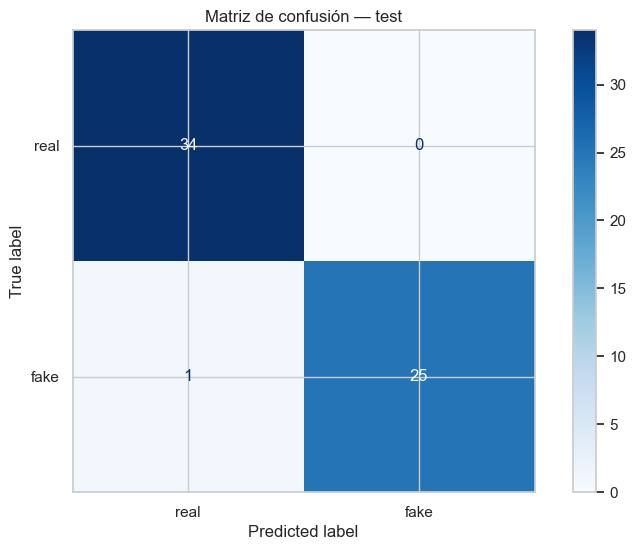

In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preparar el test igual que el train (misma limpieza y etiquetas)
test_df = pd.read_csv("data/testSpanishFakeNews.csv")
test_df.columns = test_df.columns.str.lower()
test_df["texto_limpio"] = test_df[text_col].apply(limpiar_ligero)
test_df["label"] = test_df[label_col].map(label2id)
test_ds = a_dataset_hf(test_df)

# Predecir sobre el test
salida = trainer.predict(test_ds)
y_true = salida.label_ids
y_pred = np.argmax(salida.predictions, axis=1)

print("Métricas en test:",
      {k: round(v, 4) for k, v in salida.metrics.items() if k.startswith("test_")})
print("\n", classification_report(y_true, y_pred, target_names=["real", "fake"], digits=4))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["real", "fake"]).plot(cmap="Blues")
plt.title("Matriz de confusión — test"); plt.show()

In [19]:
import time, torch

model.eval()
muestra = test_df["texto_limpio"].tolist()


with torch.no_grad():
    enc = tokenizer(muestra[0], truncation=True, max_length=MAX_LEN, return_tensors="pt")
    model(**{k: v.to(model.device) for k, v in enc.items()})

t0 = time.time()
for txt in muestra:
    enc = tokenizer(txt, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(model.device) for k, v in enc.items()}   # <-- mover los datos a la GPU
    with torch.no_grad():
        model(**enc)
print(f"Tiempo medio por noticia: {(time.time() - t0) / len(muestra) * 1000:.0f} ms")

# ¿Se equivoca más en textos cortos? (chequeo del sesgo de longitud)
test_df["pred"] = y_pred
test_df["n_palabras"] = test_df["texto_limpio"].str.split().str.len()
ok  = test_df[test_df.label == test_df.pred]
err = test_df[test_df.label != test_df.pred]
print(f"\nErrores: {len(err)}/{len(test_df)}")
print("Longitud media (palabras) — aciertos:", int(ok['n_palabras'].mean()),
      "| errores:", int(err['n_palabras'].mean()) if len(err) else "—")

Tiempo medio por noticia: 49 ms

Errores: 1/60
Longitud media (palabras) — aciertos: 404 | errores: 870


### Conclusiones de la Fase 4
1. **Desempeño en prueba:** el modelo clasificó correctamente 59 de 60 noticias (98.3 % de exactitud), un resultado incluso superior al de validación, lo que sugiere una buena capacidad de generalización. Dado el tamaño reducido del conjunto de prueba, este valor debe interpretarse con cautela.
2. **Tiempo de inferencia:** el tiempo medio fue de 49 ms por noticia (con GPU), una latencia adecuada para sostener una interacción conversacional fluida.
3. **Análisis de errores:** el único error se produjo en un texto largo (870 palabras, frente a una media de 404 en los aciertos). Este resultado es coherente con la limitación de truncamiento a 512 tokens identificada en la Fase 2: al perder más de la mitad de su contenido, el texto se queda sin información relevante para la clasificación. El error no se asocia, por tanto, a textos cortos, lo que matiza el riesgo del sesgo de longitud.